<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

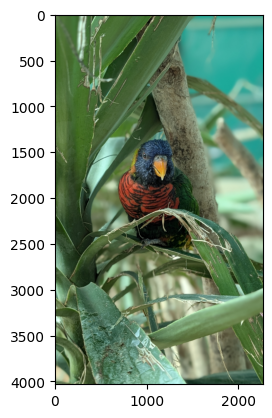


(4032, 2268, 3)


In [ ]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.image as mpimg
import urllib.request
from PIL import Image
import io

# upload images to colab
# from google.colab import files
# uploaded = files.upload()

# display image
img_1 = mpimg.imread(
    '/content/homework_images/parrot-carrot.jpg'
)

plt.imshow(img_1)
plt.show()

print(f'\n{img_1.shape}')


In [ ]:
# need to resize image, used to much RAM
img_small = Image.fromarray(img_1).resize((500, 300))
img_small = np.array(img_small)

height, width, channels = img_small.shape

flat_image = img_small.reshape(-1, width * channels)

print(img_small.shape)
print(flat_image.shape)


(300, 500, 3)
(300, 1500)


In [ ]:
U, S, VT = np.linalg.svd(
    flat_image,
    full_matrices=False
)

print(U.shape)
print(S.shape)
print(VT.shape)

(300, 300)
(300,)
(300, 1500)


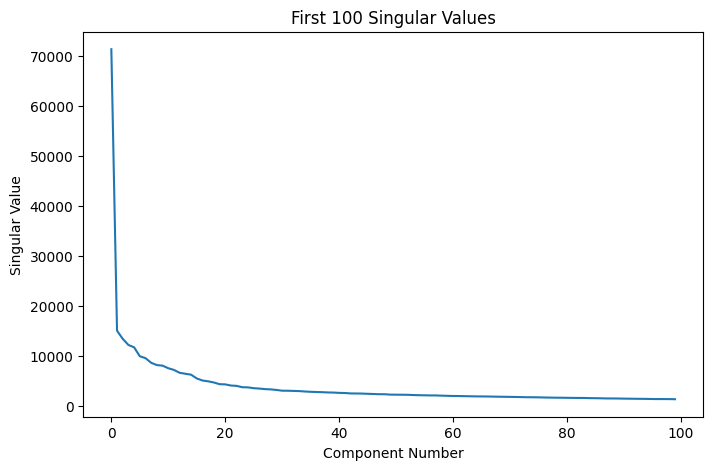

In [ ]:
k = 100
plt.figure(figsize=(8,5))
plt.plot(np.arange(k), S[:k])

plt.title("First 100 Singular Values")
plt.xlabel("Component Number")
plt.ylabel("Singular Value")

plt.show()

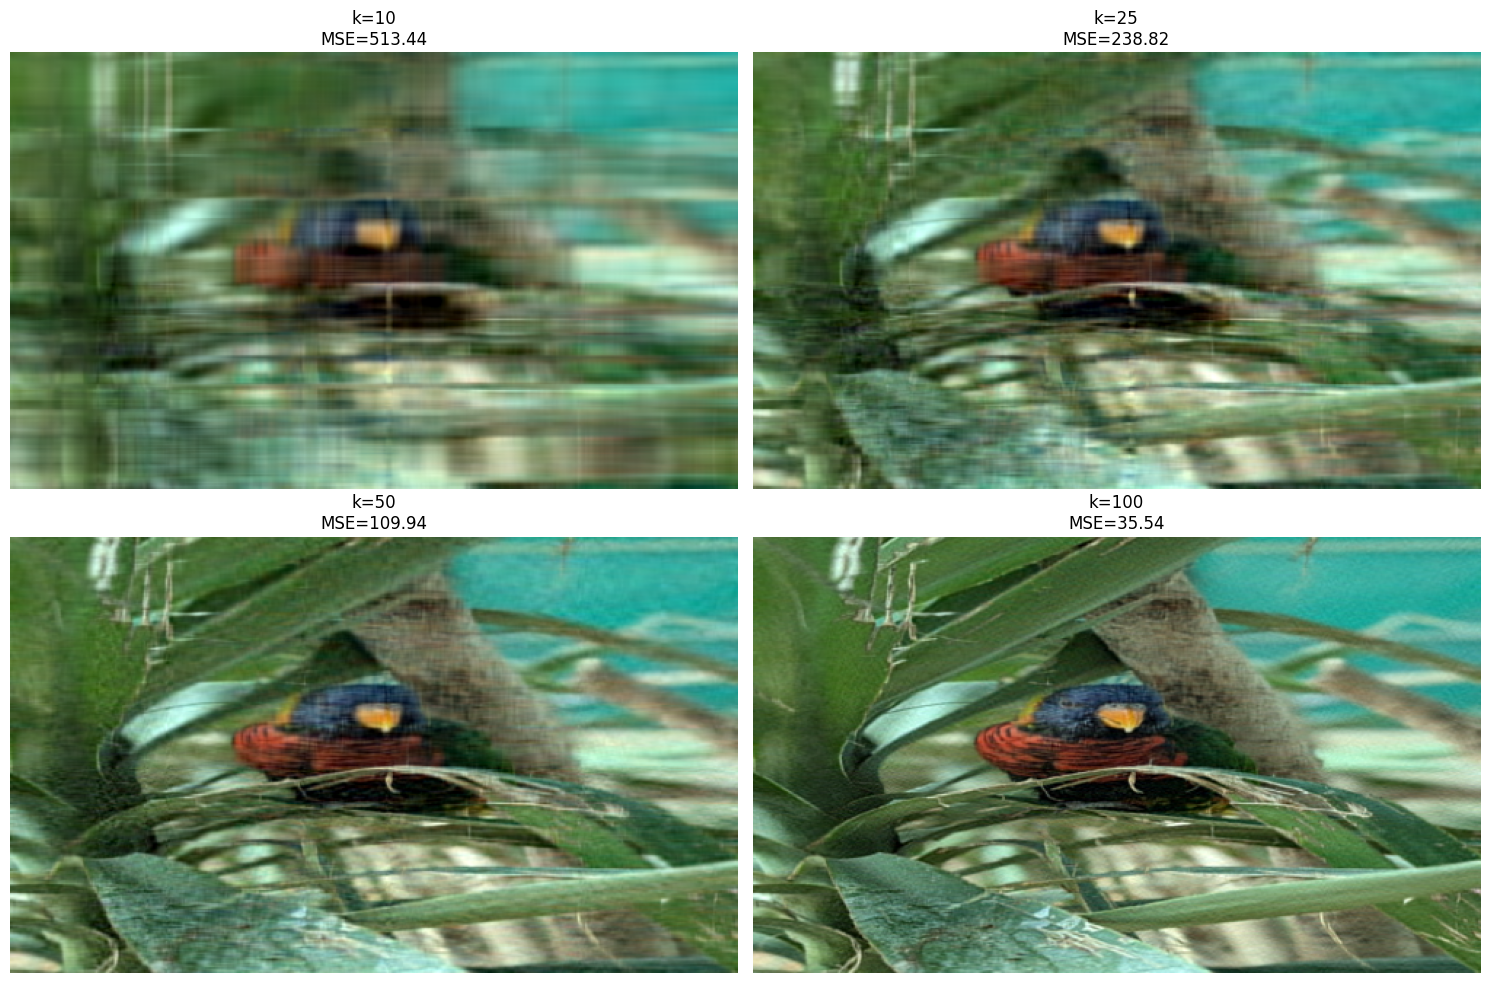

In [ ]:
k_values = [10, 25, 50, 100]

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    svd = TruncatedSVD(n_components=k)

    truncated = svd.fit_transform(flat_image)
    reconstructed = svd.inverse_transform(truncated)

    mse = np.mean((reconstructed - flat_image) ** 2)

    reconstructed = reconstructed.reshape(height, width, channels)
    reconstructed = np.clip(reconstructed, 0, 255).astype('uint8')

    plt.subplot(2, 2, i + 1)
    plt.imshow(reconstructed)
    plt.title(f"k={k}\nMSE={mse:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
svd = TruncatedSVD(n_components=100)

truncated_image = svd.fit_transform(flat_image)
reconstructed_image = svd.inverse_transform(truncated_image)

print(flat_image.shape)
print(truncated_image.shape)

print(reconstructed_image.shape)

(300, 1500)
(300, 100)
(300, 1500)


In [ ]:
reconstruction_error = np.mean(
    np.square(reconstructed_image - flat_image)
)

print(reconstruction_error)

35.54251028856462


(300, 500, 3)


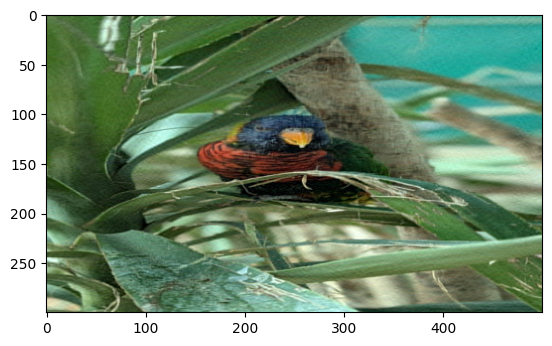

In [ ]:
print(reconstructed_image.shape)

small_height, small_width, small_channels = img_small.shape
reconstructed_image = reconstructed_image.reshape(
    small_height,
    small_width,
    small_channels
)

reconstructed_image = np.clip(
    reconstructed_image,
    0,
    255
).astype('uint8')

# plt.figure(figsize=(10, 8))
plt.imshow(reconstructed_image)
plt.show()


Testin with image 2

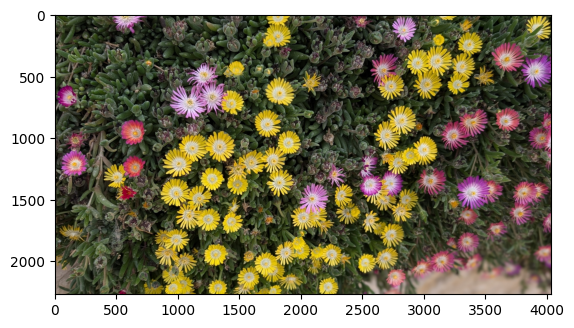


(2268, 4032, 3)


In [ ]:
img_2 = mpimg.imread(
    '/content/homework_images/flowers.jpg'
)

plt.imshow(img_2)
plt.show()

print(f'\n{img_2.shape}')

In [ ]:
img_small_2 = Image.fromarray(img_2).resize((600, 400))
img_small_2 = np.array(img_small_2)

height, width, channels = img_small_2.shape

flat_image_2 = img_small_2.reshape(-1, width * channels)

print(img_small_2.shape)
print(flat_image_2.shape)


(400, 600, 3)
(400, 1800)


In [ ]:
U, S, VT = np.linalg.svd(
    flat_image_2,
    full_matrices=False
)

print(U.shape)
print(S.shape)
print(VT.shape)

(400, 400)
(400,)
(400, 1800)


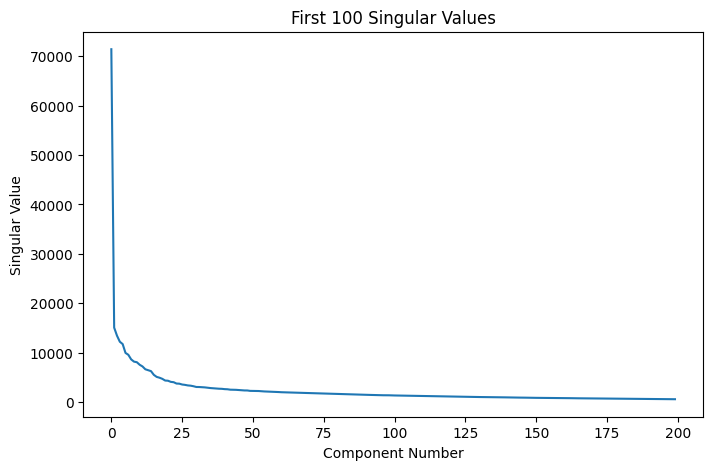

In [ ]:
k = 200
plt.figure(figsize=(8,5))
plt.plot(np.arange(k), S[:k])

plt.title("First 100 Singular Values")
plt.xlabel("Component Number")
plt.ylabel("Singular Value")

plt.show()

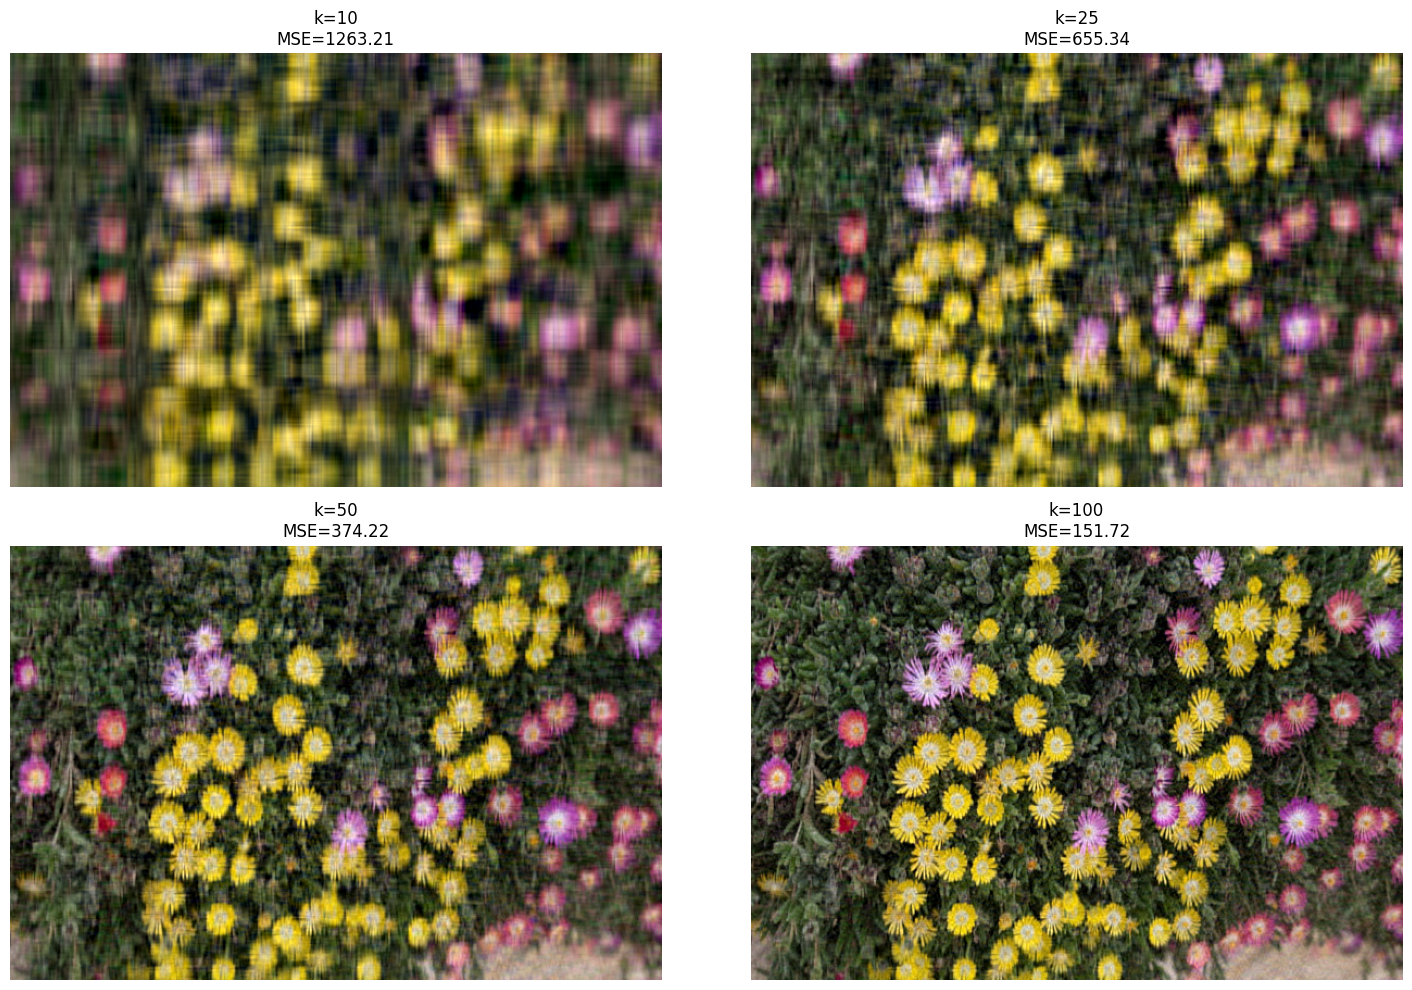

In [ ]:
plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    svd = TruncatedSVD(n_components=k)

    truncated = svd.fit_transform(flat_image_2)
    reconstructed = svd.inverse_transform(truncated)

    mse = np.mean((reconstructed - flat_image_2) ** 2)

    reconstructed = reconstructed.reshape(height, width, channels)
    reconstructed = np.clip(reconstructed, 0, 255).astype('uint8')

    plt.subplot(2, 2, i + 1)
    plt.imshow(reconstructed)
    plt.title(f"k={k}\nMSE={mse:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
svd = TruncatedSVD(n_components=100)

truncated_image = svd.fit_transform(flat_image_2)
reconstructed_image = svd.inverse_transform(truncated_image)

print(flat_image_2.shape)
print(truncated_image.shape)

print(reconstructed_image.shape)

(400, 1800)
(400, 100)
(400, 1800)


In [ ]:
reconstruction_error = np.mean(
    np.square(reconstructed_image - flat_image_2)
)

print(reconstruction_error)

151.84531344240568


(400, 1800)


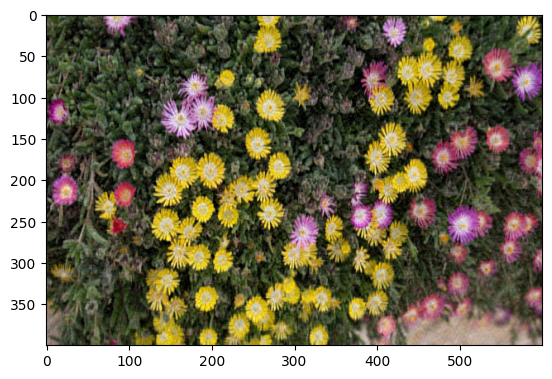

In [ ]:
print(reconstructed_image.shape)

small_height, small_width, small_channels = img_small_2.shape
reconstructed_image = reconstructed_image.reshape(
    small_height,
    small_width,
    small_channels
)

reconstructed_image = np.clip(
    reconstructed_image,
    0,
    255
).astype('uint8')

# plt.figure(figsize=(10, 8))
plt.imshow(reconstructed_image)
plt.show()

# Conclusion

The image was transformed into a two-dimensional matrix and decomposed using Singular Value Decomposition (SVD). The plot of the singular values showed that only a limited number of components contain most of the image information.

TruncatedSVD was applied using different values of k (10, 25, 50, and 100). The results demonstrated that increasing the number of retained components improves the visual quality of the reconstructed image and reduces the reconstruction error (MSE).

For small values of k, the reconstructed image loses important details and appears blurred. For larger values of k, the image becomes much closer to the original image while still achieving dimensionality reduction.

Therefore, SVD can be effectively used for image compression, providing a balance between storage reduction and image quality.
